In [2]:
import pandas as pd
import numpy as np

In [3]:
data = pd.read_csv("/Users/aftaabmulla/Neural-Networks/DataSet/dog-breed-identification/labels.csv")

In [4]:
data.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


In [5]:
data.tail()

,id,breed
10217,ffd25009d635cfd16e793503ac5edef0,borzoi
10218,ffd3f636f7f379c51ba3648a9ff8254f,dandie_dinmont
10219,ffe2ca6c940cddfee68fa3cc6c63213f,airedale
10220,ffe5f6d8e2bff356e9482a80a6e29aac,miniature_pinscher
10221,fff43b07992508bc822f33d8ffd902ae,chesapeake_bay_retriever


# Getting our WorkSpace Ready

In [7]:
import tensorflow as tf

In [4]:
print(f"TensorFlow Version : {tf.__version__}")

TensorFlow Version : 2.16.2


In [9]:
print("Yes", "GPU available" if tf.config.list_physical_devices("GPU") else "Not available")

Yes GPU available


# Loading our Data Labels

In [6]:
data["breed"].value_counts()

breed
scottish_deerhound      126
maltese_dog             117
afghan_hound            116
entlebucher             115
bernese_mountain_dog    114
                       ... 
golden_retriever         67
komondor                 67
brabancon_griffon        67
eskimo_dog               66
briard                   66
Name: count, Length: 120, dtype: int64

In [7]:
import matplotlib.pyplot as plt

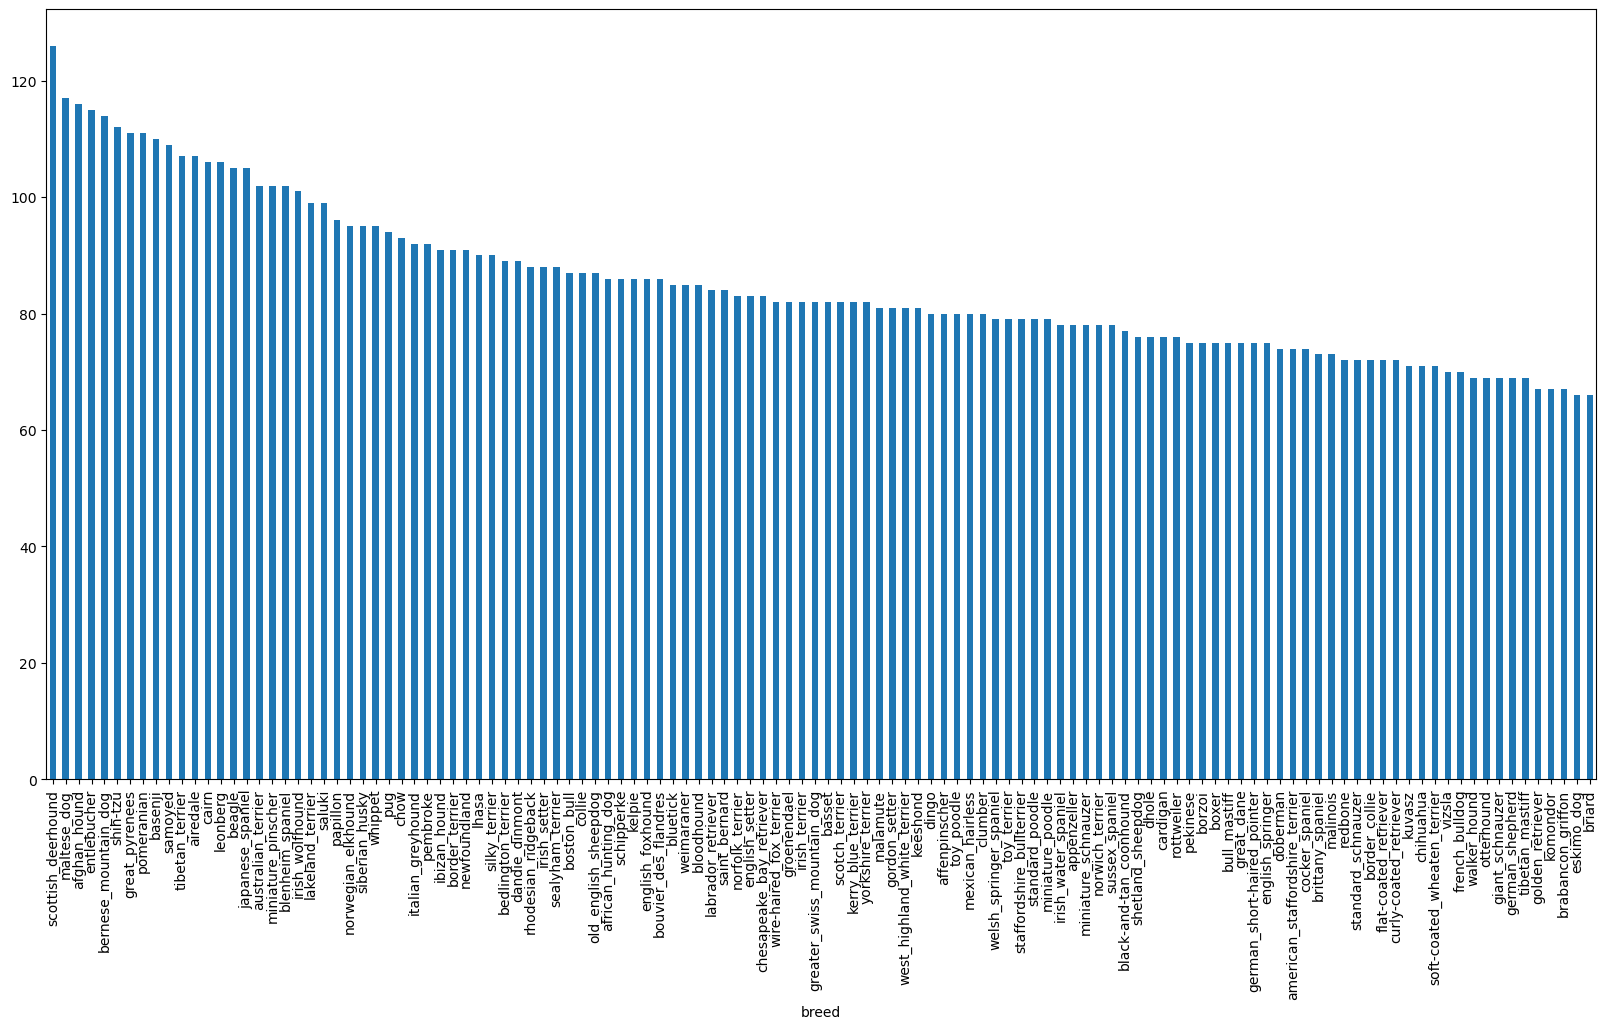

In [8]:
data["breed"].value_counts().plot.bar(figsize=(20, 10));

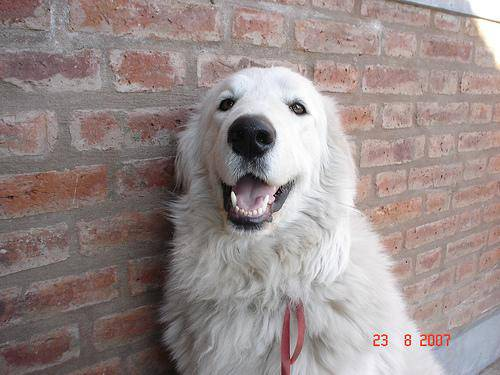

In [9]:
from IPython.display import Image
Image("/Users/aftaabmulla/Neural-Networks/DataSet/dog-breed-identification/train/0a0c223352985ec154fd604d7ddceabd.jpg")

In [10]:
filenames = ["/Users/aftaabmulla/Neural-Networks/DataSet/dog-breed-identification/train/" + fname + ".jpg"for fname in data["id"]]

filenames[:10]

['/Users/aftaabmulla/Neural-Networks/DataSet/dog-breed-identification/train/000bec180eb18c7604dcecc8fe0dba07.jpg',
 '/Users/aftaabmulla/Neural-Networks/DataSet/dog-breed-identification/train/001513dfcb2ffafc82cccf4d8bbaba97.jpg',
 '/Users/aftaabmulla/Neural-Networks/DataSet/dog-breed-identification/train/001cdf01b096e06d78e9e5112d419397.jpg',
 '/Users/aftaabmulla/Neural-Networks/DataSet/dog-breed-identification/train/00214f311d5d2247d5dfe4fe24b2303d.jpg',
 '/Users/aftaabmulla/Neural-Networks/DataSet/dog-breed-identification/train/0021f9ceb3235effd7fcde7f7538ed62.jpg',
 '/Users/aftaabmulla/Neural-Networks/DataSet/dog-breed-identification/train/002211c81b498ef88e1b40b9abf84e1d.jpg',
 '/Users/aftaabmulla/Neural-Networks/DataSet/dog-breed-identification/train/00290d3e1fdd27226ba27a8ce248ce85.jpg',
 '/Users/aftaabmulla/Neural-Networks/DataSet/dog-breed-identification/train/002a283a315af96eaea0e28e7163b21b.jpg',
 '/Users/aftaabmulla/Neural-Networks/DataSet/dog-breed-identification/train/003d

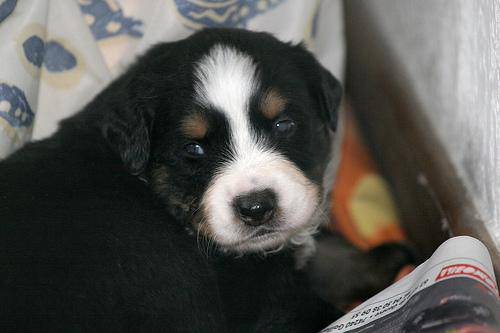

In [11]:
Image(filenames[3219])

# Converting Image into tensors

In [12]:
labels = data["breed"].to_numpy()

In [13]:
labels

array(['boston_bull', 'dingo', 'pekinese', ..., 'airedale',
       'miniature_pinscher', 'chesapeake_bay_retriever'],
      shape=(10222,), dtype=object)

In [14]:
unique_data = np.unique(labels)

In [15]:
unique_data

array(['affenpinscher', 'afghan_hound', 'african_hunting_dog', 'airedale',
       'american_staffordshire_terrier', 'appenzeller',
       'australian_terrier', 'basenji', 'basset', 'beagle',
       'bedlington_terrier', 'bernese_mountain_dog',
       'black-and-tan_coonhound', 'blenheim_spaniel', 'bloodhound',
       'bluetick', 'border_collie', 'border_terrier', 'borzoi',
       'boston_bull', 'bouvier_des_flandres', 'boxer',
       'brabancon_griffon', 'briard', 'brittany_spaniel', 'bull_mastiff',
       'cairn', 'cardigan', 'chesapeake_bay_retriever', 'chihuahua',
       'chow', 'clumber', 'cocker_spaniel', 'collie',
       'curly-coated_retriever', 'dandie_dinmont', 'dhole', 'dingo',
       'doberman', 'english_foxhound', 'english_setter',
       'english_springer', 'entlebucher', 'eskimo_dog',
       'flat-coated_retriever', 'french_bulldog', 'german_shepherd',
       'german_short-haired_pointer', 'giant_schnauzer',
       'golden_retriever', 'gordon_setter', 'great_dane',
      

In [16]:
boolean_labels = [labels == unique_data for labels in labels]

In [17]:
boolean_labels

[array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False]),
 array([False, False, False, False, False, Fal

In [18]:
print(labels[0])
print()
print(np.where(labels[0] == unique_data))
print()
print(boolean_labels[0].argmax())
print()
print(boolean_labels[0].astype(int))

boston_bull

(array([19]),)

19

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


# Creating our own Validation Set

In [19]:
X = filenames
y = boolean_labels

In [20]:
NUM_IMAGES = 1000

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X[:NUM_IMAGES],
    y[:NUM_IMAGES],
    test_size=0.2,
    random_state=42
)

In [22]:
len(X_train), len(X_val), len(y_train), len(y_val)

(800, 200, 800, 200)